/opt/miniconda3/envs/virtualmicroscopy/lib/python3.11/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


Cupy implementation is not available. Make sure you have the right version of Cupy and CUDA installed.
Loading sample of size: [5000, 5000]
Resetting stage position to center position
Acquiring image...


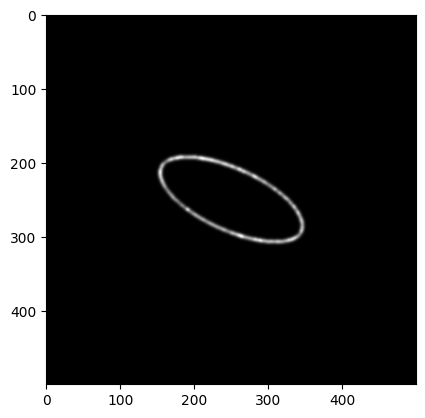

In [1]:
import math
from matplotlib import pyplot as plt
from maicroscopy_sandbox import mAIcroscopySandbox
from maicroscopy_sandbox.samples.ellipsoid import Ellipsoid
from maicroscopy_sandbox.smartSRRF import smartSRRF

microscope = mAIcroscopySandbox(fov_size=[500, 500])
sample = Ellipsoid(
    sample_size=microscope.stage_size,
    bleaching_rate=0.05,
    n_objects=20,
    movement_rate=5,
    movement_probability=0.0,
    axis_deformation_probability=0.0,
    axis_deformation_rate=0.1,
    rotation=math.pi*0.5,
    rotation_probability=0.0,
    mode="Edges",
)
microscope.set_laser_power(100)
frame = microscope.load_sample(sample, acquire=True)
plt.imshow(frame, vmin=0, cmap="gray")

Stage Moved to position: [2550, 2550]. Acquiring image...
(500, 500)


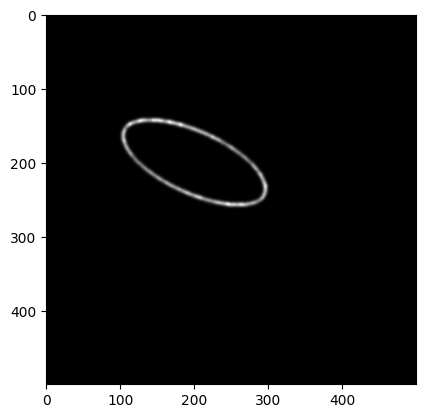

In [2]:
new_frame = microscope.move_stage([50, 50], acquire=True)
plt.imshow(new_frame, vmin=0, cmap="gray")
print(new_frame.shape)

Querying the Agent...
Agent chose: opencl
Agent: ShiftMagnify_catmull_rom using opencl ran in 0.015125208010431379 seconds
(1, 2000, 2000)
Agent: eSRRF_ST using opencl ran in 0.10381337499711663 seconds
Agent: eSRRF_ST using opencl ran in 0.10476199997356161 seconds


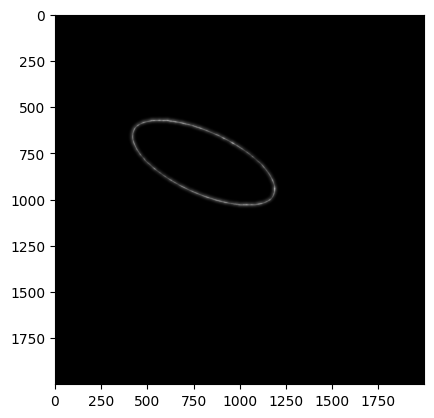

3.1012659072875977
Agent: eSRRF_ST using opencl ran in 0.1021145420090761 seconds


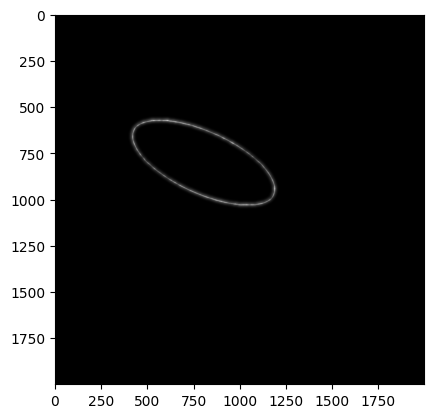

4.042938232421875
Agent: eSRRF_ST using opencl ran in 0.10617358298623003 seconds


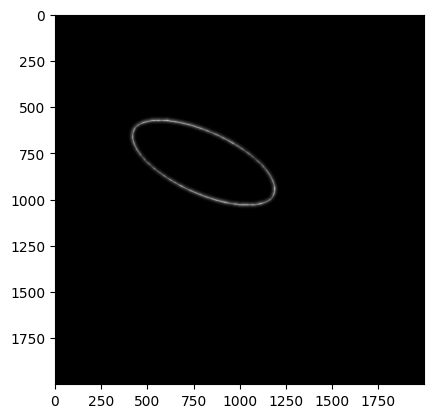

4.148237705230713
Agent: eSRRF_ST using opencl ran in 0.10242079198360443 seconds


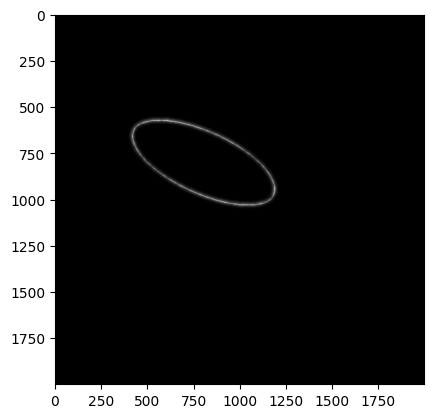

4.148237705230713


In [3]:
from maicroscopy_sandbox import smartSRRF

output = smartSRRF(microscope, plot=True)

In [4]:
import tifffile

#tifffile.imwrite("test_stack.tif", stack)